## Step 1: Import the required Python packages

In [5]:
import os
import numpy as np
import urllib.request
import requests

import openpyxl

## Step 2: Scrape text from the main page of the webpage

In [37]:
import urllib.request
from bs4 import BeautifulSoup

url = "https://cbfa-jbib.org/index.php/jbib"

#Add a header so the site treats this like a normal browser request
headers = {"User-Agent": "Mozilla/5.0"}
req = urllib.request.Request(url, headers=headers)

page = urllib.request.urlopen(req)
html = page.read()

soup = BeautifulSoup(html, "html.parser")

text = soup.get_text()

print(text)

 





		Journal of Biblical Integration in Business
					










Skip to main content
Skip to main navigation menu
Skip to site footer
















					Current
				



					Archives
				



					About
				



										About the Journal
									



										Submissions
									



										Contact
									








			Search
		


				Search
			










					Register
				



					Login
				













				Current Issue
			

				Vol 28 No 1 (2025)
			







					Published:
				

					2025-12-09
				





					Dialogue
				





			Honoring God in a Publicly Traded Corporation: Inspiration from Service Master and the Writings of C. William Pollard
					



			Kent Saunders
		





		
	Articles

	








			Charles Feeney: An Example of Biblical Giving and Living
					



			Brian Porter
		





		
	Articles

	








			The Pedagogical Power of Holistic Biography
							
					A Response to “Honoring God in a Publicly Traded Corporation” and “Charles Feeney”
				




			

## Step 3: Setup working directory

In [15]:
os.chdir('/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 4 - Web Scraping')

In [12]:
os.getcwd()

'/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 4 - Web Scraping'

## Step 4: Screenshot the text information

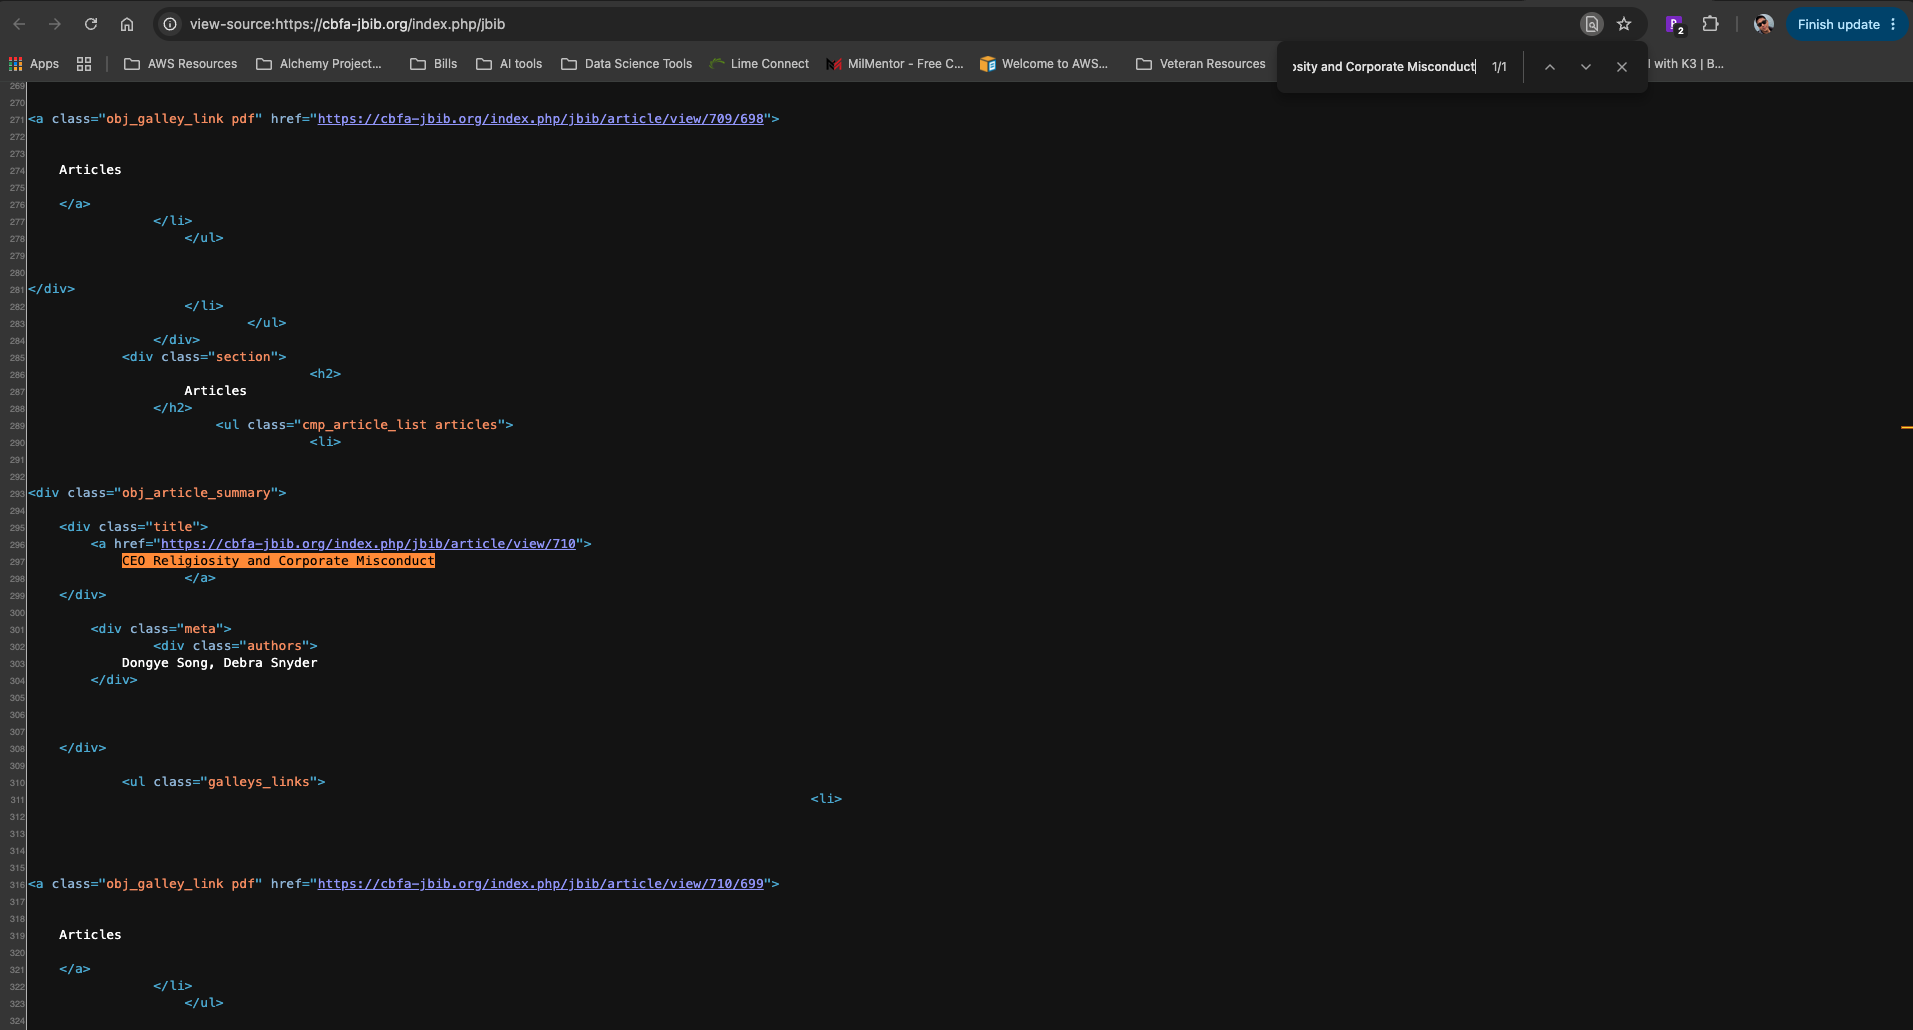

## Step 5: Extract URLs and text info using "requests" and "BeautifulSoup packages"

In [21]:
url = "https://cbfa-jbib.org/index.php/jbib/issue/view/53"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

articles = soup.find_all("div", class_="obj_article_summary")

#Goes through each articles
for article in articles:
     #Looks for the first link (<a> tag) inside this article
    link_tag = article.find("a")

    #Only continue if a link was actually found
    if link_tag:
        title = link_tag.get_text(strip=True)
        link = link_tag["href"]
        print("Title:", title)
        print("URL:", link)
        print()

Title: Mimetic Desire and the Discipline of Marketing: Implications for Marketing Practitioners
URL: https://cbfa-jbib.org/index.php/jbib/article/view/617

Title: Fraud, Whistleblowing, And Sins Of Omission: A Call To Action
URL: https://cbfa-jbib.org/index.php/jbib/article/view/618

Title: Christ, Trust, and the Twelve Disciples: The Roles of Cognitive and Affective Trust through Tuckman’s Four Stages of Group Development
URL: https://cbfa-jbib.org/index.php/jbib/article/view/620

Title: The Relationship of the Fruits of the Spirit with Person-Supervisor Fit
URL: https://cbfa-jbib.org/index.php/jbib/article/view/621

Title: Biblical Perspectives on Free Trade Policy
URL: https://cbfa-jbib.org/index.php/jbib/article/view/622

Title: Spiritual Sowing in the Secular Marketplace
URL: https://cbfa-jbib.org/index.php/jbib/article/view/623

Title: Do Christian CEOs make a difference? Empirical evidence from the S&P 500
URL: https://cbfa-jbib.org/index.php/jbib/article/view/624

Title: Consci

## Step 6: Consolidate urls and text info into a single data frame

In [33]:
import pandas as pd

url = "https://cbfa-jbib.org/index.php/jbib/issue/view/53"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

articles = soup.find_all("div", class_="obj_article_summary")

urls = []
link_types = []
authors_list = []

for article in articles:

    authors_tag = article.find("div", class_="authors")
    authors = authors_tag.get_text(strip=True) if authors_tag else "No author listed"

    links = article.find_all("a")
    
    for link in links:
        urls.append(link["href"])
        link_types.append(link.get_text(strip=True))
        authors_list.append(authors)

df = pd.DataFrame({
    "Title": link_types,
    "URL": urls,
    "Author": authors_list
})

print(df.shape)
df

(28, 3)


,Title,URL,Author
0,Mimetic Desire and the Discipline of Marketing...,https://cbfa-jbib.org/index.php/jbib/article/v...,"David Burns, Yvonne Smith"
1,Article,https://cbfa-jbib.org/index.php/jbib/article/v...,"David Burns, Yvonne Smith"
2,"Fraud, Whistleblowing, And Sins Of Omission: A...",https://cbfa-jbib.org/index.php/jbib/article/v...,Tim Bergsma
3,Article,https://cbfa-jbib.org/index.php/jbib/article/v...,Tim Bergsma
4,"Christ, Trust, and the Twelve Disciples: The R...",https://cbfa-jbib.org/index.php/jbib/article/v...,Joseph Kuvshinikov
5,Article,https://cbfa-jbib.org/index.php/jbib/article/v...,Joseph Kuvshinikov
6,The Relationship of the Fruits of the Spirit w...,https://cbfa-jbib.org/index.php/jbib/article/v...,"Bruce Winston, Mihai Bocarnea"
7,Article,https://cbfa-jbib.org/index.php/jbib/article/v...,"Bruce Winston, Mihai Bocarnea"
8,Biblical Perspectives on Free Trade Policy,https://cbfa-jbib.org/index.php/jbib/article/v...,"Mary Kay Copeland, Cora Barnhart"
9,Article,https://cbfa-jbib.org/index.php/jbib/article/v...,"Mary Kay Copeland, Cora Barnhart"


## Step 7: Export dataframe to an Excel file

In [34]:
url = "https://cbfa-jbib.org/index.php/jbib/issue/view/53"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")
articles = soup.find_all("div", class_="obj_article_summary")

urls = []
titles_authors = []

for article in articles:
    authors_tag = article.find("div", class_="authors")
    authors = authors_tag.get_text(strip=True) if authors_tag else "No author listed"
    links = article.find_all("a")

    for link in links:
        title = link.get_text(strip=True)
        urls.append(link["href"])
        titles_authors.append(f"{title}\n{authors}")

df = pd.DataFrame({
    "Title & Author": titles_authors,
    "URL": urls
})

print(df.shape)
df

(28, 2)


,Title & Author,URL
0,Mimetic Desire and the Discipline of Marketing...,https://cbfa-jbib.org/index.php/jbib/article/v...
1,"Article\nDavid Burns, Yvonne Smith",https://cbfa-jbib.org/index.php/jbib/article/v...
2,"Fraud, Whistleblowing, And Sins Of Omission: A...",https://cbfa-jbib.org/index.php/jbib/article/v...
3,Article\nTim Bergsma,https://cbfa-jbib.org/index.php/jbib/article/v...
4,"Christ, Trust, and the Twelve Disciples: The R...",https://cbfa-jbib.org/index.php/jbib/article/v...
5,Article\nJoseph Kuvshinikov,https://cbfa-jbib.org/index.php/jbib/article/v...
6,The Relationship of the Fruits of the Spirit w...,https://cbfa-jbib.org/index.php/jbib/article/v...
7,"Article\nBruce Winston, Mihai Bocarnea",https://cbfa-jbib.org/index.php/jbib/article/v...
8,Biblical Perspectives on Free Trade Policy\nMa...,https://cbfa-jbib.org/index.php/jbib/article/v...
9,"Article\nMary Kay Copeland, Cora Barnhart",https://cbfa-jbib.org/index.php/jbib/article/v...


In [35]:
file_name = "Articles2022.xlsx"

if os.path.exists(file_name):
    os.remove(file_name)
    print(f"Existing file '{file_name}' removed.")
else:
    print(f"No existing file named '{file_name}' found.")

df.to_excel(file_name, index=False)
print(f"Data exported to '{file_name}'.")

No existing file named 'Articles2022.xlsx' found.
Data exported to 'Articles2022.xlsx'.
